# Phase 2+3 — YOLOv26s Person + best.pt NO-* (single-pass §6, SAHI §7-8) — ponytail minimal

**Goal:** validate `NO-*` violation from `best.pt` (Kaggle 100e, 10-class), `yolo26s.pt` Person only for Exception Log. Phase 2 (§6) single-pass P/R/F1; Phase 3 (§7-8) manual SAHI tiling `slice 640 overlap 0.2 -> sliced NO-* -> NMS 0.5`. No pose/head_roi, no sahi pip, one function plus NMS.  
**valid 114 / test 82** — valid tuning, test locked (Gate: Rec gain >=0.03 and Prec drop <=0.03).


## 1 · Setup


In [10]:
import time, random, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, cv2
from ultralytics import YOLO

sns.set_theme(style="whitegrid")
random.seed(42); np.random.seed(42)
print("ultralytics:", __import__("ultralytics").__version__)

try:
    _nb = Path(__file__)
    REPO_ROOT = _nb.resolve().parents[2]
except NameError:
    cur = Path.cwd()
    REPO_ROOT = cur
    for cand in [cur, cur.parent, cur.parent.parent]:
        if (cand / "YOLO8.ipynb").exists() or (cand / ".git").exists():
            REPO_ROOT = cand; break
print("REPO_ROOT:", REPO_ROOT)


ultralytics: 8.4.127
REPO_ROOT: e:\work\P0-safety


## 2 · Data

`data/` is gitignored (`/.gitignore: /data`). If missing, visuals fall back to repo images and quant is skipped with a restore hint.


In [11]:
CLASS_NAMES = ["Hardhat","Mask","NO-Hardhat","NO-Mask","NO-Safety Vest","Person","Safety Cone","Safety Vest","machinery","vehicle"]
NO_CLASSES = {"NO-Hardhat","NO-Mask","NO-Safety Vest"}
PERSON_CLS = CLASS_NAMES.index("Person")

DATA_DIR = REPO_ROOT / "data" / "css-data"
REFERENCE_WEIGHTS = REPO_ROOT / "data" / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt"

for split in ["train","valid","test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*"))) if lbl_dir.exists() else 0
    print(f"{split:6s} images={n_img:5d} labels={n_lbl:5d} exists={img_dir.exists()}")
print("best.pt exists:", REFERENCE_WEIGHTS.exists())
if not DATA_DIR.exists():
    print("\n`data/css-data` not found locally (gitignored). To restore:")
    print("  - Kaggle: snehilsanyal/construction-site-safety-image-dataset-roboflow (2,801 imgs, 10 classes)")
    print("  - Or copy from your backup that produced valid=114 / test=82.")


train  images= 2605 labels= 2605 exists=True
valid  images=  114 labels=  114 exists=True
test   images=   82 labels=   82 exists=True
best.pt exists: True


## 3 · Models — yolo26s (Person) + best.pt (NO-*)

`yolo26s.pt` auto-downloads on first `YOLO("yolo26s.pt")` via hub. `best.pt` is required for `NO-*`; if missing, only the yolo26s Person sanity visuals run.


In [12]:
def load_model(path_str, label):
    t0=time.time()
    m=YOLO(path_str)
    print(f"{label:16s} -> {path_str}  {list(m.names.values())[:5]}... ({len(m.names)} cls)  {time.time()-t0:.1f}s")
    return m

# yolo26s for Person (COCO, class 0 = person)
yolo26s_path = REPO_ROOT / "yolo26s.pt"
if not yolo26s_path.exists():
    # also check experiment/two-stage-detection/yolo26s.pt (cached earlier)
    alt = REPO_ROOT / "experiment" / "two-stage-detection" / "yolo26s.pt"
    yolo26s_path = alt if alt.exists() else Path("yolo26s.pt")
model_person = load_model(str(yolo26s_path), "yolo26s-person")

model_best = None
if REFERENCE_WEIGHTS.exists():
    model_best = load_model(str(REFERENCE_WEIGHTS), "best-NO-*")
    print("best.pt classes:", list(model_best.names.values()))
else:
    print("best.pt MISSING — violation quant will be skipped until data/ is restored")


yolo26s-person   -> e:\work\P0-safety\experiment\two-stage-detection\yolo26s.pt  ['person', 'bicycle', 'car', 'motorcycle', 'airplane']... (80 cls)  0.0s
best-NO-*        -> e:\work\P0-safety\data\results_yolov8n_100e\kaggle\working\runs\detect\train\weights\best.pt  ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest']... (10 cls)  0.0s
best.pt classes: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


## 4 · Helpers — Person boxes, NO-* boxes, GT, nearest-person log


In [13]:
def person_class_id(model):
    for k,v in model.names.items():
        if v=="person": return k
    return 0

def extract_person_boxes(result, model, conf_thr=0.25):
    if result.boxes is None or len(result.boxes)==0: return []
    pid=person_class_id(model)
    out=[]
    for i in range(len(result.boxes)):
        if int(result.boxes.cls[i].item())==pid and float(result.boxes.conf[i].item())>=conf_thr:
            x1,y1,x2,y2=result.boxes.xyxy[i].tolist()
            out.append([x1,y1,x2,y2,float(result.boxes.conf[i].item())])
    return out

def extract_no_boxes(result, model, conf_thr=0.25):
    if result.boxes is None or len(result.boxes)==0: return []
    # lookup NO-* ids by name from this model's taxonomy (best.pt is 10-class)
    no_ids={k for k,v in model.names.items() if v in NO_CLASSES}
    out=[]
    for i in range(len(result.boxes)):
        cid=int(result.boxes.cls[i].item())
        conf=float(result.boxes.conf[i].item())
        if cid in no_ids and conf>=conf_thr:
            x1,y1,x2,y2=result.boxes.xyxy[i].tolist()
            out.append([x1,y1,x2,y2,conf,model.names[cid]])
    return out

def parse_violation_gt(label_path):
    # image-level violation = any NO-* label present (dataset GT)
    p=Path(label_path)
    if not p.exists(): return False
    for line in p.read_text().splitlines():
        if not line.strip(): continue
        cid=int(line.split()[0])
        if CLASS_NAMES[cid] in NO_CLASSES:
            return True
    return False

def violation_pred(no_boxes):
    return len(no_boxes) > 0

def nearest_person_for_no(no_box, person_boxes):
    # Euclidean nearest center; no threshold — orphan NO-* still logs with nearest person or None
    if not person_boxes: return None, None
    cx_no=(no_box[0]+no_box[2])/2; cy_no=(no_box[1]+no_box[3])/2
    best=None; best_d=float('inf')
    for idx,p in enumerate(person_boxes):
        cx_p=(p[0]+p[2])/2; cy_p=(p[1]+p[3])/2
        d=(cx_no-cx_p)**2 + (cy_no-cy_p)**2
        if d < best_d: best_d=d; best=idx
    return best, best_d

def per_person_rows(person_boxes, no_boxes):
    # returns list of dicts for Exception Log preview
    rows=[]
    for idx,p in enumerate(person_boxes):
        rows.append({"person_idx": idx, "person_xyxy": p[:4], "person_conf": p[4], "viol": False, "no_class": None, "no_conf": None})
    for nb in no_boxes:
        pi,_=nearest_person_for_no(nb, person_boxes)
        if pi is not None:
            rows[pi]["viol"]=True
            # keep highest-conf NO-* if multiple map to same person
            if rows[pi]["no_conf"] is None or nb[4] > rows[pi]["no_conf"]:
                rows[pi]["no_class"]=nb[5]; rows[pi]["no_conf"]=nb[4]
    return rows


## 5 · Visual sanity — 6 images: yolo26s Person + best.pt NO-* (if available)

Green = yolo26s Person, Red = NO-* (violation), White = GT NO-* labels. Title shows `GT viol` vs `pred viol` + person/no counts.


sample: ['maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg', 'casino_0448_jpg.rf.090df4137a5926092c541ee5c6918868.jpg', '-3766-_png_jpg.rf.81ead992d4b8047ec7beb28b7532cf0a.jpg', 'youtube-510_jpg.rf.62f82e36d134d53587edb48f291986f4.jpg', 'ppe_0665_jpg.rf.1dad479f7f54b2a7127cf18ef74ffd85.jpg', 'Mask2_mov-11_jpg.rf.34ddcb1a619624541a2cca4400b7cd92.jpg']
CONF_PERSON=0.25 CONF_NO=0.25 IMGSZ=640
maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg GT_viol=True pred_viol=True  person=1 NO-*=3 GT_NO-*=2
 person_idx                                                            person_xyxy  person_conf  viol   no_class  no_conf
          0 [1.831817626953125, 233.89111328125, 492.9640197753906, 638.669921875]     0.966296  True NO-Hardhat 0.840417


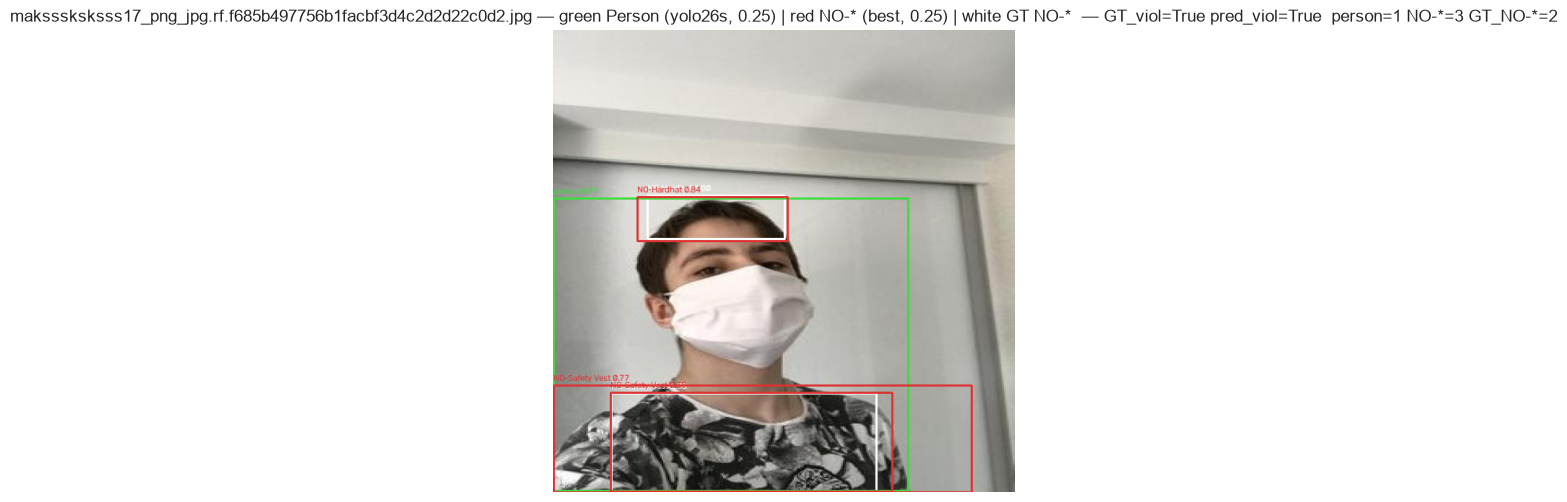

casino_0448_jpg.rf.090df4137a5926092c541ee5c6918868.jpg GT_viol=False pred_viol=False  person=0 NO-*=0 GT_NO-*=0


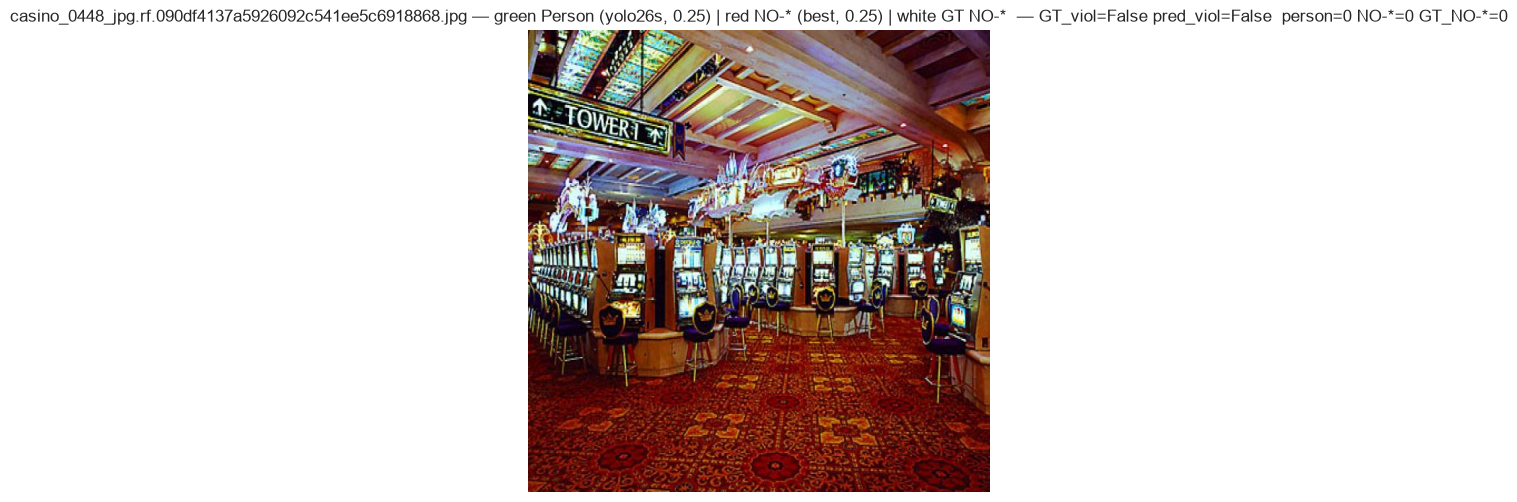

-3766-_png_jpg.rf.81ead992d4b8047ec7beb28b7532cf0a.jpg GT_viol=True pred_viol=True  person=11 NO-*=21 GT_NO-*=23
 person_idx                                                                       person_xyxy  person_conf  viol       no_class  no_conf
          0   [270.41680908203125, 0.2149200439453125, 404.6563720703125, 282.07806396484375]     0.634045  True NO-Safety Vest 0.890005
          1    [107.04350280761719, 250.0169677734375, 377.27423095703125, 486.2924499511719]     0.587979  True NO-Safety Vest 0.899305
          2     [415.93463134765625, 228.5680389404297, 558.8421020507812, 440.0861511230469]     0.542747  True NO-Safety Vest 0.819462
          3         [98.5992202758789, 362.528076171875, 324.929443359375, 639.3170776367188]     0.508437  True NO-Safety Vest 0.597819
          4            [449.7010498046875, 75.470703125, 550.4078369140625, 214.710205078125]     0.437962  True NO-Safety Vest 0.660297
          5      [578.6784057617188, 64.9117431640625, 639.707153

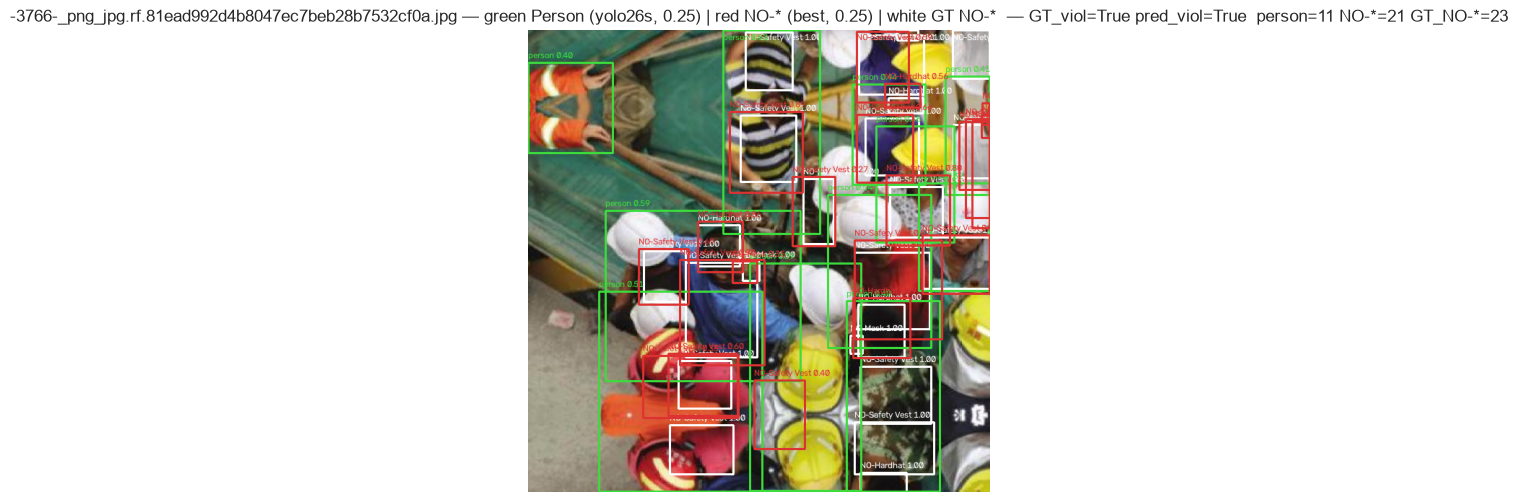

youtube-510_jpg.rf.62f82e36d134d53587edb48f291986f4.jpg GT_viol=False pred_viol=False  person=1 NO-*=0 GT_NO-*=0
 person_idx                                                                    person_xyxy  person_conf  viol no_class no_conf
          0 [195.8421173095703, 373.98175048828125, 255.41134643554688, 596.2689819335938]     0.598477 False     None    None


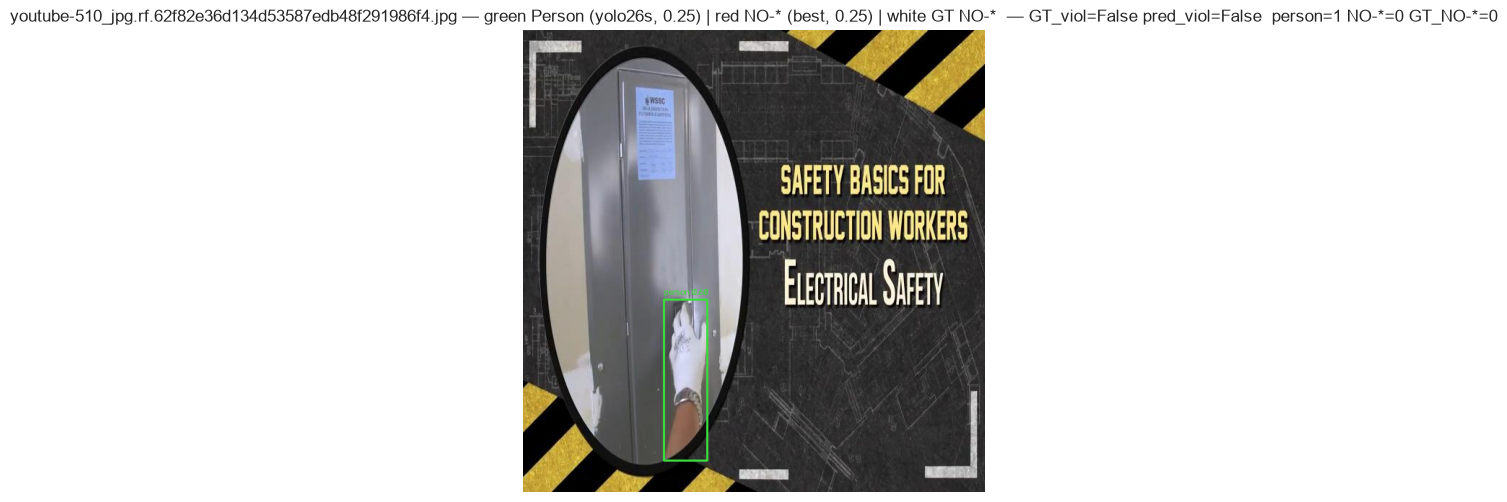

ppe_0665_jpg.rf.1dad479f7f54b2a7127cf18ef74ffd85.jpg GT_viol=True pred_viol=True  person=7 NO-*=15 GT_NO-*=14
 person_idx                                                                    person_xyxy  person_conf  viol       no_class  no_conf
          0               [506.6875, 192.4355010986328, 607.2275390625, 638.9619750976562]     0.944518  True        NO-Mask 0.723785
          1  [67.23844909667969, 255.8365936279297, 174.76783752441406, 638.9737548828125]     0.935645  True NO-Safety Vest 0.906419
          2         [427.0567321777344, 179.54197692871094, 513.7060546875, 638.755859375]     0.933199  True        NO-Mask 0.816374
          3   [150.07525634765625, 223.87957763671875, 243.4282684326172, 639.45263671875]     0.917307  True NO-Safety Vest 0.942662
          4 [316.59710693359375, 181.01104736328125, 415.3246154785156, 636.8742065429688]     0.917268  True     NO-Hardhat 0.893661
          5            [216.74362182617188, 206.82369995117188, 302.82379150390625, 64

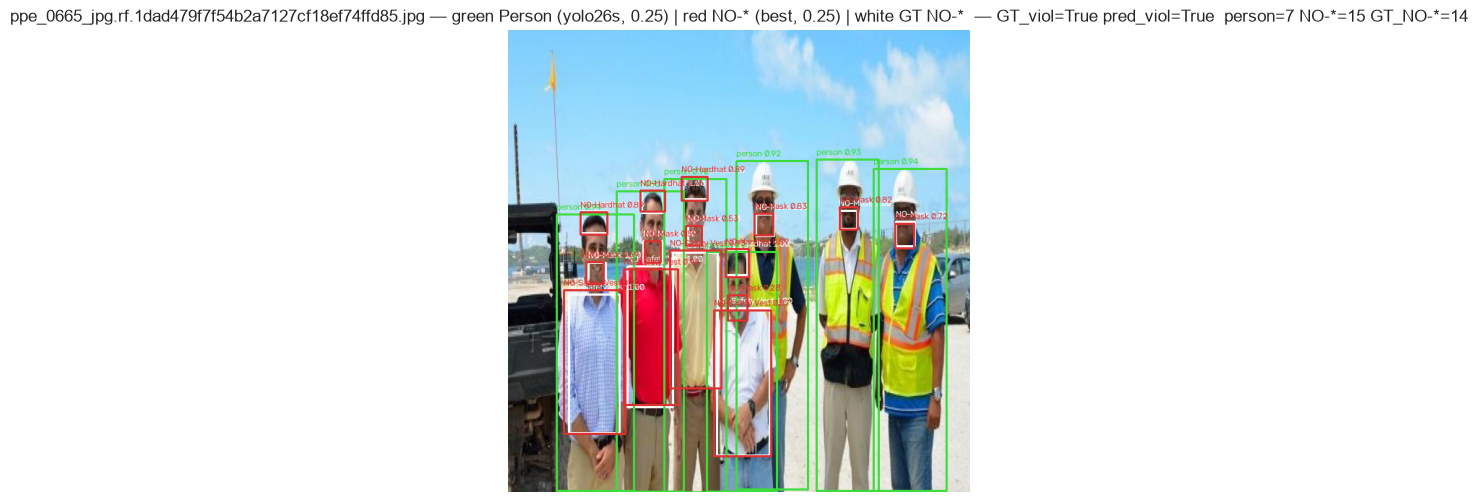

Mask2_mov-11_jpg.rf.34ddcb1a619624541a2cca4400b7cd92.jpg GT_viol=True pred_viol=True  person=1 NO-*=2 GT_NO-*=2
 person_idx                                                    person_xyxy  person_conf  viol   no_class  no_conf
          0 [0.0, 227.69003295898438, 639.378173828125, 639.5975341796875]     0.665406  True NO-Hardhat 0.840536


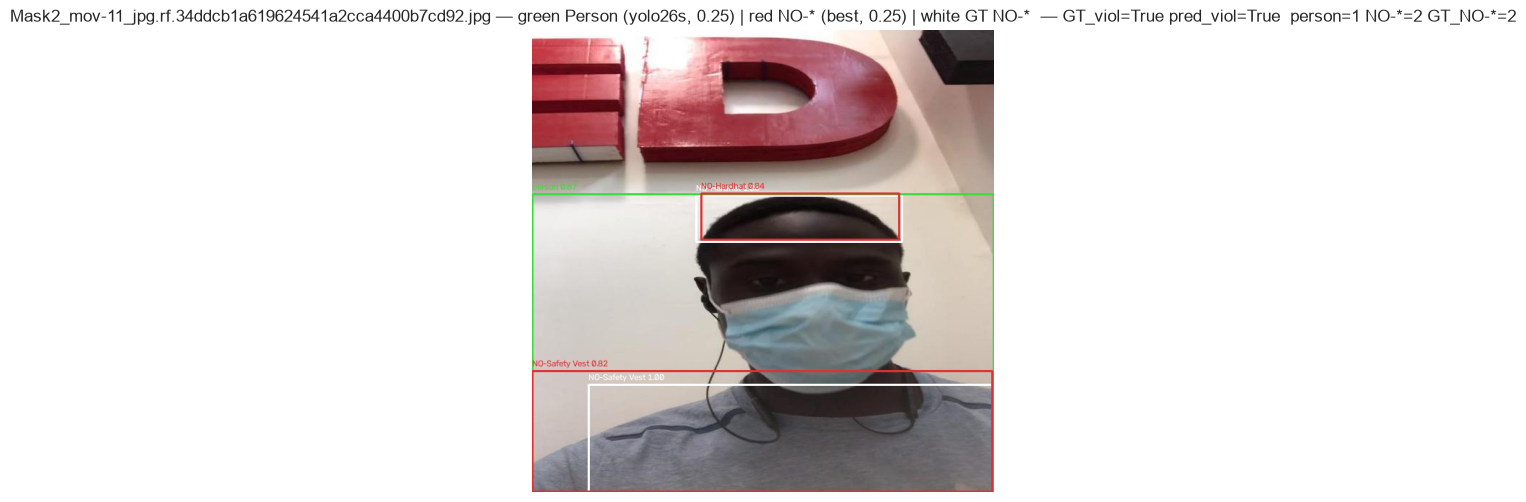

In [14]:
CONF_PERSON=0.25
CONF_NO=0.25
IMGSZ=640

def draw_boxes(img, boxes, color):
    out=img.copy()
    for b in boxes:
        x1,y1,x2,y2=b[0],b[1],b[2],b[3]; conf=b[4]
        label=b[5] if len(b)>5 else "person"
        cv2.rectangle(out,(int(x1),int(y1)),(int(x2),int(y2)),color,2)
        cv2.putText(out,f"{label} {conf:.2f}",(int(x1),max(14,int(y1)-6)),cv2.FONT_HERSHEY_SIMPLEX,0.42,color,1,cv2.LINE_AA)
    return out

def parse_no_gt_boxes(label_path, W, H):
    p=Path(label_path)
    out=[]
    if not p.exists(): return out
    for line in p.read_text().splitlines():
        if not line.strip(): continue
        parts=line.split()
        cid=int(parts[0]); cx,cy,w,h=map(float, parts[1:5])
        if CLASS_NAMES[cid] in NO_CLASSES:
            x1,y1=cx*W - w*W/2, cy*H - h*H/2
            x2,y2=cx*W + w*W/2, cy*H + h*H/2
            out.append([x1,y1,x2,y2,1.0,CLASS_NAMES[cid]])
    return out

if (DATA_DIR / "valid" / "images").exists():
    pool=list((DATA_DIR / "valid" / "images").glob("*")) + list((DATA_DIR / "test" / "images").glob("*"))
else:
    pool=list(REPO_ROOT.rglob("*.jpg"))[:6]
sample_imgs=random.sample(pool, min(6,len(pool))) if pool else []
print("sample:", [p.name for p in sample_imgs])
print(f"CONF_PERSON={CONF_PERSON} CONF_NO={CONF_NO} IMGSZ={IMGSZ}")

for img_path in sample_imgs:
    img=cv2.imread(str(img_path))
    if img is None: continue
    rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    H,W=rgb.shape[:2]
    # Person from yolo26s
    r_p=model_person(str(img_path), verbose=False, imgsz=IMGSZ)[0]
    p_boxes=extract_person_boxes(r_p, model_person, CONF_PERSON)
    # NO-* from best.pt if available
    no_boxes=[]
    if model_best is not None:
        r_b=model_best(str(img_path), verbose=False, imgsz=IMGSZ)[0]
        no_boxes=extract_no_boxes(r_b, model_best, CONF_NO)
    # GT
    gt_no_boxes=[]
    gt_viol=False
    for lbl_dir in [DATA_DIR / "valid" / "labels", DATA_DIR / "test" / "labels"]:
        cand=lbl_dir / (img_path.stem + ".txt")
        if cand.exists():
            gt_no_boxes=parse_no_gt_boxes(str(cand), W, H)
            gt_viol=parse_violation_gt(str(cand))
            break
    pred_viol=violation_pred(no_boxes) if model_best is not None else None
    # draw: base rgb -> overlay GT white first, then persons green, then NO-* red
    vis=cv2.cvtColor(rgb,cv2.COLOR_RGB2BGR)
    vis=cv2.cvtColor(vis,cv2.COLOR_BGR2RGB)
    if gt_no_boxes:
        vis=draw_boxes(vis, gt_no_boxes, (255,255,255))  # white GT
    vis=draw_boxes(vis, p_boxes, (60,220,60))
    if no_boxes:
        vis=draw_boxes(vis, no_boxes, (220,50,50))
    tag=f"GT_viol={gt_viol} pred_viol={pred_viol}  person={len(p_boxes)} NO-*={len(no_boxes)} GT_NO-*={len(gt_no_boxes)}"
    print(f"{img_path.name:40s} {tag}")
    if p_boxes or no_boxes or gt_no_boxes:
        # per-person preview
        rows=per_person_rows(p_boxes, no_boxes)
        if rows:
            print(pd.DataFrame(rows).to_string(index=False))
    plt.figure(figsize=(10,6)); plt.imshow(vis); plt.axis("off")
    plt.title(f"{img_path.name} \u2014 green Person (yolo26s, {CONF_PERSON}) | red NO-* (best, {CONF_NO}) | white GT NO-*  \u2014 " + tag)
    plt.show()


## 6 · Quantitative — image-level violation P/R/F1 (yolo26s Person + NO-* single-pass)

Primary metric is **image-level** `violation = exists(NO-*)` (GT = any `NO-*` label). Person grounding does not affect `P/R/F1` — it is for the per-person Exception Log.  
Control `A` = `best.pt` NO-* alone (image-level). `yolo26s+NO-*` uses same `NO-*` signal; Person only changes the per-person assignment and latency. Sweeps on `valid` only; `test` is reported but not tuned.


=== Control A (best.pt NO-* alone, image-level) ===
valid conf_no=0.25  P=0.969 R=0.887 F1=0.926  TP=63 FP=2 TN=41 FN=8  ms=38 n=114
valid conf_no=0.40  P=1.000 R=0.845 F1=0.916  TP=60 FP=0 TN=43 FN=11  ms=31 n=114
test  conf_no=0.25  P=1.000 R=0.833 F1=0.909  TP=40 FP=0 TN=34 FN=8  ms=31 n=82
test  conf_no=0.40  P=1.000 R=0.812 F1=0.897  TP=39 FP=0 TN=34 FN=9  ms=32 n=82

=== yolo26s Person + best.pt NO-* (two-stage single-pass, image-level unchanged, latency + orphan) ===
valid p=0.25 no=0.25  P=0.969 R=0.887 F1=0.926  TP=63 FP=2 TN=41 FN=8  ms=109 orphan=4 n=114
valid p=0.25 no=0.40  P=1.000 R=0.845 F1=0.916  TP=60 FP=0 TN=43 FN=11  ms=108 orphan=3 n=114
valid p=0.35 no=0.25  P=0.969 R=0.887 F1=0.926  TP=63 FP=2 TN=41 FN=8  ms=112 orphan=4 n=114
valid p=0.35 no=0.40  P=1.000 R=0.845 F1=0.916  TP=60 FP=0 TN=43 FN=11  ms=125 orphan=3 n=114
test  p=0.25 no=0.25  P=1.000 R=0.833 F1=0.909  TP=40 FP=0 TN=34 FN=8  ms=126 orphan=2 n=82
test  p=0.25 no=0.40  P=1.000 R=0.812 F1=0.897  TP=39 F

,split,person_conf,no_conf,n,TP,FP,TN,FN,prec,rec,f1,ms,orphan
0,valid,0.25,0.25,114,63,2,41,8,0.969231,0.887324,0.926471,109.256778,4
1,valid,0.25,0.40,114,60,0,43,11,1.000000,0.845070,0.916031,107.790506,3
2,valid,0.35,0.25,114,63,2,41,8,0.969231,0.887324,0.926471,112.292553,4
3,valid,0.35,0.40,114,60,0,43,11,1.000000,0.845070,0.916031,125.001219,3
4,test,0.25,0.25,82,40,0,34,8,1.000000,0.833333,0.909091,125.971460,2
5,test,0.25,0.40,82,39,0,34,9,1.000000,0.812500,0.896552,122.652539,2
6,test,0.35,0.25,82,40,0,34,8,1.000000,0.833333,0.909091,122.515085,2
7,test,0.35,0.40,82,39,0,34,9,1.000000,0.812500,0.896552,124.490680,2


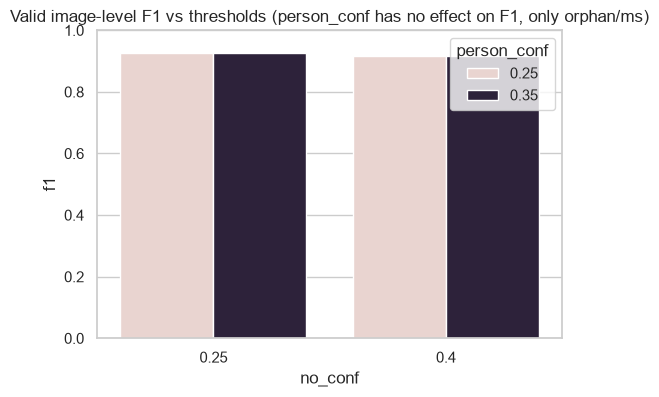

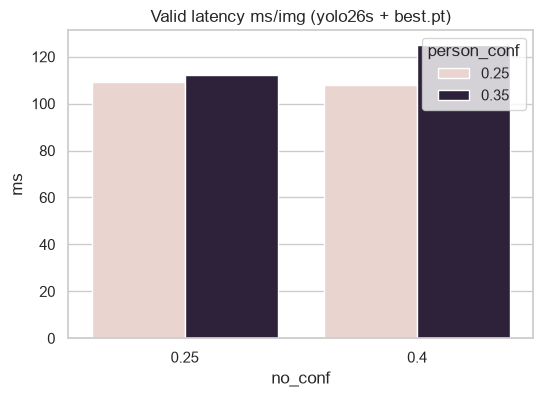

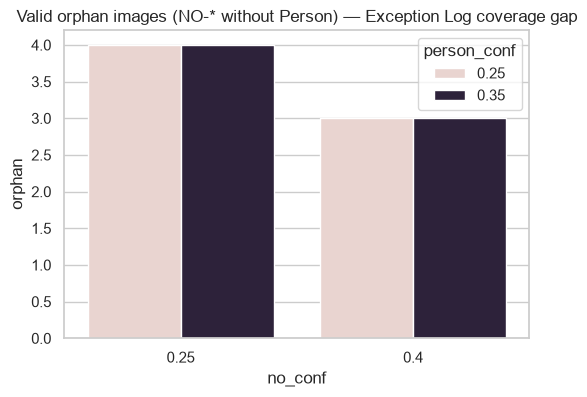


Note: image-level F1 is identical between A and yolo26s+NO-* by design (same NO-* boxes). Differences would only appear if you changed NO-* thresholds. Key Phase-2 decision is person_conf for log coverage vs FP persons + latency, not F1.


In [15]:
def eval_violation_split(split, conf_no=0.25, imgsz=640):
    if model_best is None: return None
    img_dir=DATA_DIR / split / "images"; lbl_dir=DATA_DIR / split / "labels"
    if not img_dir.exists(): return None
    imgs=list(img_dir.glob("*"))
    TP=FP=TN=FN=0; times=[]
    for p in imgs:
        gt=parse_violation_gt(str(lbl_dir / (p.stem+".txt")))
        t0=time.time()
        res=model_best(str(p), verbose=False, imgsz=imgsz)[0]
        times.append((time.time()-t0)*1000)
        pred=violation_pred(extract_no_boxes(res, model_best, conf_no))
        if gt and pred: TP+=1
        elif not gt and pred: FP+=1
        elif not gt and not pred: TN+=1
        else: FN+=1
    prec=TP/max(1,TP+FP); rec=TP/max(1,TP+FN); f1=2*prec*rec/max(1e-9,prec+rec)
    return dict(n=len(imgs), TP=TP, FP=FP, TN=TN, FN=FN, prec=prec, rec=rec, f1=f1, ms=np.mean(times))

def eval_violation_with_person(split, conf_person=0.25, conf_no=0.25, imgsz=640):
    # same image-level metric, but also runs yolo26s Person to measure two-stage latency + orphan rate
    if model_best is None: return None
    img_dir=DATA_DIR / split / "images"; lbl_dir=DATA_DIR / split / "labels"
    if not img_dir.exists(): return None
    imgs=list(img_dir.glob("*"))
    TP=FP=TN=FN=0; times=[]; orphan_images=0
    for p in imgs:
        gt=parse_violation_gt(str(lbl_dir / (p.stem+".txt")))
        t0=time.time()
        r_p=model_person(str(p), verbose=False, imgsz=imgsz)[0]
        p_boxes=extract_person_boxes(r_p, model_person, conf_person)
        r_b=model_best(str(p), verbose=False, imgsz=imgsz)[0]
        no_boxes=extract_no_boxes(r_b, model_best, conf_no)
        times.append((time.time()-t0)*1000)
        pred=violation_pred(no_boxes)
        if gt and pred: TP+=1
        elif not gt and pred: FP+=1
        elif not gt and not pred: TN+=1
        else: FN+=1
        if no_boxes and not p_boxes:
            orphan_images+=1
    prec=TP/max(1,TP+FP); rec=TP/max(1,TP+FN); f1=2*prec*rec/max(1e-9,prec+rec)
    return dict(n=len(imgs), TP=TP, FP=FP, TN=TN, FN=FN, prec=prec, rec=rec, f1=f1, ms=np.mean(times), orphan=orphan_images)

if not DATA_DIR.exists() or model_best is None:
    print("Skipping quant — need data/css-data + best.pt (see \u00a72). Run \u00a75 visuals instead.")
else:
    # A control: best.pt NO-* alone (from helmet-compliance-validation.md, re-measured here for apples-to-apples)
    print("=== Control A (best.pt NO-* alone, image-level) ===")
    for split in ["valid","test"]:
        for conf in [0.25, 0.40]:
            r=eval_violation_split(split, conf_no=conf)
            if r: print(f"{split:5s} conf_no={conf:.2f}  P={r['prec']:.3f} R={r['rec']:.3f} F1={r['f1']:.3f}  TP={r['TP']} FP={r['FP']} TN={r['TN']} FN={r['FN']}  ms={r['ms']:.0f} n={r['n']}")
    print("\n=== yolo26s Person + best.pt NO-* (two-stage single-pass, image-level unchanged, latency + orphan) ===")
    rows=[]
    for split in ["valid","test"]:
        for cp in [0.25, 0.35]:
            for cn in [0.25, 0.40]:
                r=eval_violation_with_person(split, conf_person=cp, conf_no=cn)
                if r:
                    rows.append({"split": split, "person_conf": cp, "no_conf": cn, **r})
                    print(f"{split:5s} p={cp:.2f} no={cn:.2f}  P={r['prec']:.3f} R={r['rec']:.3f} F1={r['f1']:.3f}  TP={r['TP']} FP={r['FP']} TN={r['TN']} FN={r['FN']}  ms={r['ms']:.0f} orphan={r['orphan']} n={r['n']}")
    df=pd.DataFrame(rows)
    if not df.empty:
        display(df)
        # valid sweep heatmap: F1 and ms
        df_valid=df[df.split=="valid"]
        if not df_valid.empty:
            plt.figure(figsize=(6,4))
            sns.barplot(data=df_valid, x="no_conf", y="f1", hue="person_conf")
            plt.title("Valid image-level F1 vs thresholds (person_conf has no effect on F1, only orphan/ms)")
            plt.ylim(0,1); plt.show()
            plt.figure(figsize=(6,4))
            sns.barplot(data=df_valid, x="no_conf", y="ms", hue="person_conf")
            plt.title("Valid latency ms/img (yolo26s + best.pt)")
            plt.show()
            plt.figure(figsize=(6,4))
            sns.barplot(data=df_valid, x="no_conf", y="orphan", hue="person_conf")
            plt.title("Valid orphan images (NO-* without Person) — Exception Log coverage gap")
            plt.show()
    print("\nNote: image-level F1 is identical between A and yolo26s+NO-* by design (same NO-* boxes). Differences would only appear if you changed NO-* thresholds. Key Phase-2 decision is person_conf for log coverage vs FP persons + latency, not F1.")
